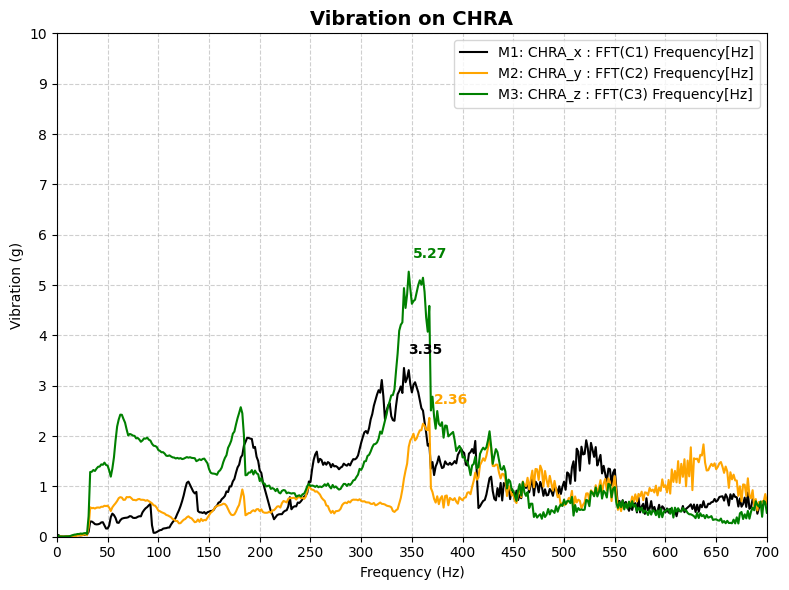

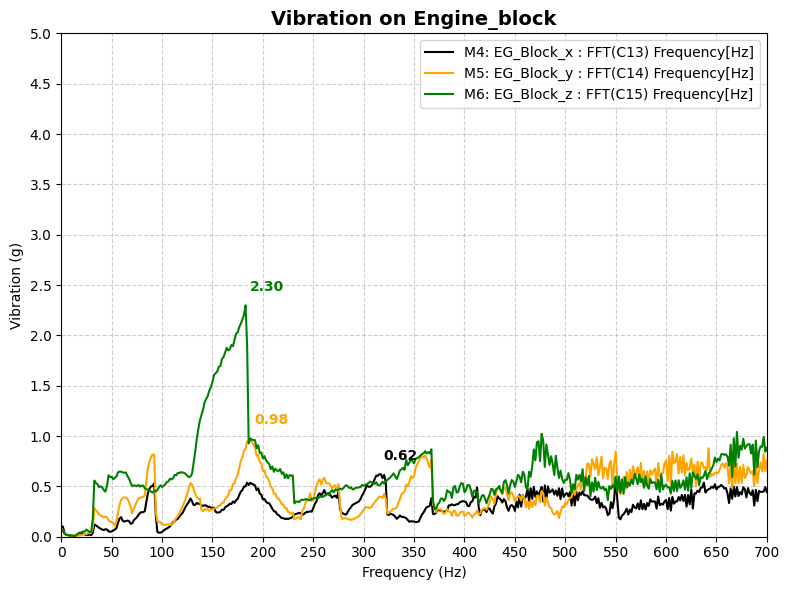

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# 1. 파일 로드 (컬럼 불일치 대응)
file_path = "Full_Load_Sweep_5500erpm.csv"
try:
    with open(file_path, 'r') as f:
        max_cols = max([len(line.split(',')) for line in f.readlines()[:20]])
    df = pd.read_csv(file_path, header=None, names=range(max_cols), low_memory=False)
except:
    df = pd.read_csv(file_path, header=None, on_bad_lines='skip', low_memory=False)

headers = df.iloc[1]
data = df.iloc[11:].reset_index(drop=True)

# 2. 6개 채널 데이터 처리 및 Magnitude 계산
channels = []
start_col, cols_per_channel = 1, 3

for i in range(6):
    col_idx = start_col + (i * cols_per_channel)
    if col_idx + 2 < df.shape[1]:
        ch_name = str(headers[col_idx]) if not pd.isna(headers[col_idx]) else f"CH{i+1}"
        
        freq = pd.to_numeric(data.iloc[:, col_idx], errors='coerce')
        real = pd.to_numeric(data.iloc[:, col_idx + 1], errors='coerce')
        imag = pd.to_numeric(data.iloc[:, col_idx + 2], errors='coerce')
        magnitude = np.sqrt(real**2 + imag**2)
        
        valid_mask = ~freq.isna() & ~magnitude.isna()
        channels.append({
            'name': ch_name, 
            'freq': freq[valid_mask].values, 
            'mag': magnitude[valid_mask].values
        })

# 3. 그래프 그리기 함수 정의
def draw_custom_plot(channel_subset, title, y_max, y_interval, x_interval=50):
    fig, ax = plt.subplots(figsize=(8, 6))
    line_colors = ['black', 'orange', 'green']
    
    for i, ch in enumerate(channel_subset):
        color = line_colors[i] if i < len(line_colors) else None
        ax.plot(ch['freq'], ch['mag'], label=ch['name'], color=color)
        
        # 최대값 찾기 (0~700Hz 범위 내)
        mask = (ch['freq'] >= 0) & (ch['freq'] <= 700)
        if any(mask):
            f_range = ch['freq'][mask]
            m_range = ch['mag'][mask]
            
            max_idx = np.argmax(m_range)
            max_f = f_range[max_idx]
            max_m = m_range[max_idx]
            
            # --- 라벨 위치 수정 (오른쪽 위로 이동) ---
            ax.annotate(f'{max_m:.2f}', 
                        xy=(max_f, max_m), 
                        xytext=(3, 10),    # (오른쪽으로 10, 위로 10 이동)
                        textcoords='offset points',
                        ha='left',          # 텍스트 시작점을 왼쪽으로 설정하여 오른쪽으로 뻗어나가게 함
                        fontsize=10,
                        fontweight='bold',
                        color=color)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Vibration (g)")
    
    ax.set_xlim(0, 700)
    ax.set_ylim(0, y_max)
    
    ax.xaxis.set_major_locator(MultipleLocator(x_interval))
    ax.yaxis.set_major_locator(MultipleLocator(y_interval))
    
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# --- 그래프 실행 ---

# 첫 번째 그래프: Vibration on CHRA
if len(channels) >= 1:
    draw_custom_plot(channels[:3], "Vibration on CHRA", 
                     y_max=10, y_interval=1, x_interval=50)

# 두 번째 그래프: Vibration on Engine_block
if len(channels) > 3:
    draw_custom_plot(channels[3:], "Vibration on Engine_block", 
                     y_max=5, y_interval=0.5, x_interval=50)

CSV 파일의 구조와 그동안 요청하신 모든 시각화 세부 사항(색상, 축 범위, 그리드 간격, 피크 라벨링 등)을 포함하여, 나중에 다른 AI에게도 동일한 결과를 얻을 수 있는 **'마스터 프롬프트'**를 작성해 드립니다.

---

### 📊 진동 데이터 분석 및 시각화 마스터 프롬프트

**[역할 설정]**
너는 파이썬 데이터 시각화 전문가이자 진동 분석 엔지니어이다. 제공된 CSV 파일을 분석하여 특정 주파수 대역의 Magnitude 그래프를 생성하는 최적화된 코드를 작성해라.

**[데이터 구조 설명]**

1. **파일 형식**: CSV (쉼표 구분), 불규칙한 컬럼 수를 가질 수 있음.
2. **헤더 정보**: 2행(Index 1)에 채널 이름이 있으며, 데이터는 12행(Index 11)부터 시작함.
3. **데이터 구성**: 각 채널은 3개의 컬럼(Frequency, Real, Imaginary)으로 구성됨.
* 예: 채널 1(B, C, D컬럼), 채널 2(E, F, G컬럼) ... 총 6개 채널 처리.


4. **계산식**: Magnitude = 

**[시각화 요구 사항]**

1. **그래프 구성**: 총 2개의 개별 Figure 생성 (각 8x6 인치).
* **그래프 1**: 채널 1~3 포함. 타이틀 "Vibration on CHRA"
* **그래프 2**: 채널 4~6 포함. 타이틀 "Vibration on Engine_block"


2. **색상 지정**: 각 그래프 내의 라인 순서에 따라 **Black, Orange, Green** 색상을 강제로 적용할 것.
3. **축 설정**:
* **공통 X축**: 범위를 0~700Hz로 제한하고, 그리드 간격(Major Locator)은 50으로 설정.
* **Y축**: 단위는 "Vibration (g)".
* 그래프 1은 최대값 10, 그리드 간격 1로 설정.
* 그래프 2는 최대값 5, 그리드 간격 0.5로 설정.




4. **피크 라벨링 (Peak Annotation)**:
* 0~700Hz 범위 내에서 각 채널의 최대 Magnitude 값을 찾을 것.
* 해당 피크 좌표 위에 Magnitude 값을 소수점 둘째 자리까지 표시.
* 라벨의 색상은 해당 라인 색상과 동일하게 맞추고, 위치는 피크 지점에서 오른쪽 위(Offset: x=3, y=10)로 이동시켜 가독성을 높일 것.


5. **기타**: 범례(Legend)는 우측 상단(upper right)에 표시하고, 배경에는 투명도 0.6의 점선(dashed) 그리드를 추가할 것.

**[출력 형태]**

* `pandas`, `numpy`, `matplotlib`를 사용하는 완성된 전체 파이썬 코드를 작성해줘.

---

### 💡 이 프롬프트 활용 팁

이 프롬프트는 사용자가 최종적으로 완성한 코드의 **모든 로직을 말(언어)로 설명한 것**입니다.

* **새로운 파일 분석 시**: 위 프롬프트에서 `file_path` 이름이나 `y_max` 수치만 살짝 바꿔서 질문하면 즉시 수정된 코드를 얻을 수 있습니다.
* **다른 AI 활용 시**: ChatGPT나 Claude 같은 다른 모델에게 위 내용을 그대로 붙여넣으면, 지금 우리가 만든 것과 똑같은 품질의 코드를 다시 짜줍니다.

추가적으로 이 데이터를 이용해 **엑셀 보고서용 자동 저장 기능**이나 **특정 주파수 피크 리스트 추출** 기능이 필요하시면 말씀해 주세요! 다시 한 번 도와드리겠습니다.

주요 코드 로직 설명데이터 로드: 일반적인 CSV와 달리 상단에 설정 정보가 있고 데이터 시작점이 뒤에 있는 경우를 처리하기 위해 iloc[11:]를 사용했습니다.Magnitude 계산: 진동 센서 데이터는 보통 복소수(실수+허수) 형태로 들어오는데, 이를 물리적인 크기로 변환하기 위해 피타고라스 정리($\sqrt{\text{real}^2 + \text{imag}^2}$)를 사용합니다.Peak 검출: 진동 분석에서 가장 중요한 것은 어느 주파수에서 가장 큰 진동이 발생하는지 찾는 것입니다. np.argmax를 통해 이를 찾아 그래프에 숫자로 표시해 줍니다.혹시 코드 중에서 특정 함수의 동작 원리(예: pd.to_numeric이나 annotate)에 대해 더 자세히 알고 싶으신가요?

In [ ]:
import pandas as pd              # 데이터 판다스(표 형태 데이터 처리)
import numpy as np               # 수치 계산(제곱근, 배열 처리 등)
import matplotlib.pyplot as plt  # 그래프 시각화
from matplotlib.ticker import MultipleLocator # 그래프 축 간격 조절

# ---------------------------------------------------------
# 1. 파일 로드 (데이터 모양이 일정하지 않을 때를 대비)
# ---------------------------------------------------------
file_path = "Full_Load_Sweep_5500erpm.csv"

try:
    # 파일을 한 줄씩 읽어서 가장 칸(Column)이 많은 행의 개수를 미리 파악합니다.
    with open(file_path, 'r') as f:
        max_cols = max([len(line.split(',')) for line in f.readlines()[:20]])
    
    # 파악한 칸 개수(max_cols)를 기준으로 데이터를 읽어옵니다.
    df = pd.read_csv(file_path, header=None, names=range(max_cols), low_memory=False)
except:
    # 위 방법이 실패할 경우, 에러가 나는 줄은 건너뛰고 읽습니다.
    df = pd.read_csv(file_path, header=None, on_bad_lines='skip', low_memory=False)

# 엑셀 파일의 2번째 줄(인덱스 1)을 컬럼 이름(헤더)으로 설정
headers = df.iloc[1]
# 실제 데이터는 12번째 줄(인덱스 11)부터 시작하므로 그 윗부분은 잘라냄
data = df.iloc[11:].reset_index(drop=True)

# ---------------------------------------------------------
# 2. 6개 채널 데이터 처리 및 진동 크기(Magnitude) 계산
# ---------------------------------------------------------
channels = []
start_col, cols_per_channel = 1, 3  # 데이터가 1번 칸부터 3칸씩(주파수, 실수, 허수) 반복됨

for i in range(6):  # 총 6개의 채널을 반복 처리
    col_idx = start_col + (i * cols_per_channel)
    
    # 읽어올 칸이 데이터 전체 범위 안에 있는지 확인
    if col_idx + 2 < df.shape[1]:
        # 채널 이름 가져오기 (비어있으면 CH1, CH2... 식으로 이름 붙임)
        ch_name = str(headers[col_idx]) if not pd.isna(headers[col_idx]) else f"CH{i+1}"
        
        # 문자열로 되어 있을 수 있는 데이터를 숫자로 변환 (오류 데이터는 NaN 처리)
        freq = pd.to_numeric(data.iloc[:, col_idx], errors='coerce')      # 주파수
        real = pd.to_numeric(data.iloc[:, col_idx + 1], errors='coerce')  # 실수부
        imag = pd.to_numeric(data.iloc[:, col_idx + 2], errors='coerce')  # 허수부
        
        # 복소수의 크기 계산: sqrt(실수² + 허수²)
        magnitude = np.sqrt(real**2 + imag**2)
        
        # 숫자가 아닌 값(NaN)을 제거하기 위한 필터 생성
        valid_mask = ~freq.isna() & ~magnitude.isna()
        
        # 깨끗하게 정리된 데이터를 리스트에 저장
        channels.append({
            'name': ch_name, 
            'freq': freq[valid_mask].values, 
            'mag': magnitude[valid_mask].values
        })

# ---------------------------------------------------------
# 3. 그래프 그리기 함수 정의 (반복되는 작업을 함수로 만듦)
# ---------------------------------------------------------
def draw_custom_plot(channel_subset, title, y_max, y_interval, x_interval=50):
    fig, ax = plt.subplots(figsize=(8, 6)) # 그래프 크기 설정
    line_colors = ['black', 'orange', 'green'] # 선 색상 지정
    
    for i, ch in enumerate(channel_subset):
        color = line_colors[i] if i < len(line_colors) else None
        # X축은 주파수(freq), Y축은 진동 크기(mag)로 그래프 그림
        ax.plot(ch['freq'], ch['mag'], label=ch['name'], color=color)
        
        # 특정 범위(0~700Hz) 안에서 가장 큰 값(Peak) 찾기
        mask = (ch['freq'] >= 0) & (ch['freq'] <= 700)
        if any(mask):
            f_range = ch['freq'][mask]
            m_range = ch['mag'][mask]
            
            max_idx = np.argmax(m_range) # 가장 큰 값의 위치
            max_f = f_range[max_idx]     # 그때의 주파수
            max_m = m_range[max_idx]     # 그때의 진동 크기
            
            # 그래프 위에 최대값 수치 표시 (어노테이션)
            ax.annotate(f'{max_m:.2f}', 
                        xy=(max_f, max_m), 
                        xytext=(3, 10),      # 점으로부터 (오른쪽으로 3, 위로 10) 떨어진 곳에 표시
                        textcoords='offset points',
                        ha='left', 
                        fontsize=10,
                        fontweight='bold',
                        color=color)
    
    # 그래프 제목 및 축 이름 설정
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Vibration (g)")
    
    # 보여줄 범위 설정 (0~700Hz)
    ax.set_xlim(0, 700)
    ax.set_ylim(0, y_max)
    
    # 눈금 간격 설정
    ax.xaxis.set_major_locator(MultipleLocator(x_interval))
    ax.yaxis.set_major_locator(MultipleLocator(y_interval))
    
    ax.legend(loc='upper right')       # 범례 표시
    ax.grid(True, linestyle='--', alpha=0.6) # 배경에 점선 그리드 추가
    plt.tight_layout()                 # 그래프 요소들이 겹치지 않게 조정
    plt.show()                         # 화면에 출력

# ---------------------------------------------------------
# 4. 그래프 실행 (실제 데이터 적용)
# ---------------------------------------------------------

# 첫 번째 그래프: 1~3번 채널 (CHRA 진동)
if len(channels) >= 1:
    draw_custom_plot(channels[:3], "Vibration on CHRA", 
                     y_max=10, y_interval=1, x_interval=50)

# 두 번째 그래프: 4~6번 채널 (엔진 블록 진동)
if len(channels) > 3:
    draw_custom_plot(channels[3:], "Vibration on Engine_block", 
                     y_max=5, y_interval=0.5, x_interval=50)